In [1]:
import pycisTopic
import pickle
import pandas as pd
import os
from collections import Counter
import numpy as np

In [2]:
from pycisTopic.clust_vis import (
    find_clusters,
    run_umap,
    run_tsne,
    plot_metadata,
    plot_topic,
    cell_topic_heatmap
)

In [3]:
%%time
out_dir = "pycistopic_outs/"
cto_infile = open(out_dir + 'cisTopicObject.pkl', 'rb')
cistopic_obj = pickle.load(cto_infile)
cto_infile.close()

CPU times: user 519 ms, sys: 5.69 s, total: 6.2 s
Wall time: 7.61 s


In [4]:
cistopic_obj.cell_data

,cisTopic_log_nr_acc,cisTopic_log_nr_frag,cisTopic_nr_frag,cisTopic_nr_acc,ATAC_barcode,sample_id,leiden,donor_id,study,age_status,...,tsse,cell_type,tech_plus_study,age_group,decade,final_cell_type,cell_or_nuclei,disease,disease_and_age_status,group
HCAHeartST11064575_HCAHeartST11023240:GGTTGCGGTTAACACG-1___cisTopic,4.77194,4.895671,78645,59148,HCAHeartST11064575_HCAHeartST11023240:GGTTGCGG...,HCAHeartST11064575_HCAHeartST11023240,1,Kanemaru 2023:AH1-Nuclei_Multiome-v1,Kanemaru 2023,postnatal,...,5,Cardiomyocyte,Multiome-v1_Kanemaru 2023,middle,4.0,Cardiomyocyte,Nuclei,ND,N:postnatal,N:postnatal_Cardiomyocyte
ENCSR185NXG:CACTAAGGACTGATCC___cisTopic,3.716588,3.738463,5476,5207,ENCSR185NXG:CACTAAGGACTGATCC,ENCSR185NXG,1,ENCODE v4 (Snyder):ENCSR067BOK,ENCODE v4 (Snyder),postnatal,...,5,Cardiomyocyte,Multiome-v1_ENCODE v4 (Snyder),middle,5.0,Cardiomyocyte,Nuclei,ND,N:postnatal,N:postnatal_Cardiomyocyte
ENCSR233KYH:CCAGAAACTTGCCTTT___cisTopic,3.467756,3.487138,3070,2936,ENCSR233KYH:CCAGAAACTTGCCTTT,ENCSR233KYH,2,ENCODE v4 (Snyder):ENCSR076ZLE,ENCODE v4 (Snyder),postnatal,...,5,Cardiomyocyte,Multiome-v1_ENCODE v4 (Snyder),old,6.0,Cardiomyocyte,Nuclei,ND,N:postnatal,N:postnatal_Cardiomyocyte
HCAHeartST10773165_HCAHeartST10781062:TGGATTCAGAGGCTAA-1___cisTopic,4.437957,4.544329,35021,27413,HCAHeartST10773165_HCAHeartST10781062:TGGATTCA...,HCAHeartST10773165_HCAHeartST10781062,2,Kanemaru 2023:AH1-Nuclei_Multiome-v1,Kanemaru 2023,postnatal,...,5,Cardiomyocyte,Multiome-v1_Kanemaru 2023,middle,4.0,Cardiomyocyte,Nuclei,ND,N:postnatal,N:postnatal_Cardiomyocyte
HCAHeartST10773165_HCAHeartST10781062:AGTAATCGTTTATCGC-1___cisTopic,4.3367,4.41504,26004,21712,HCAHeartST10773165_HCAHeartST10781062:AGTAATCG...,HCAHeartST10773165_HCAHeartST10781062,1,Kanemaru 2023:AH1-Nuclei_Multiome-v1,Kanemaru 2023,postnatal,...,5,Cardiomyocyte,Multiome-v1_Kanemaru 2023,middle,4.0,Cardiomyocyte,Nuclei,ND,N:postnatal,N:postnatal_Cardiomyocyte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10X_ATAC_CK354:TAGTCCCGTCCAACCG-1___cisTopic,3.774882,3.805025,6383,5955,10X_ATAC_CK354:TAGTCCCGTCCAACCG-1,10X_ATAC_CK354,7,Kuppe 2022:P9,Kuppe 2022,postnatal,...,5,Myeloid,10X_ATAC_Kuppe 2022,middle,5.0,Myeloid,Nuclei,AMI,Y:postnatal,Y:postnatal_Myeloid
10X_ATAC_CK388:CAGCTAAAGTGATAAC-1___cisTopic,3.508126,3.527759,3371,3222,10X_ATAC_CK388:CAGCTAAAGTGATAAC-1,10X_ATAC_CK388,7,Kuppe 2022:P18,Kuppe 2022,postnatal,...,5,Myeloid,10X_ATAC_Kuppe 2022,old,6.0,Myeloid,Nuclei,ICM,Y:postnatal,Y:postnatal_Myeloid
10X_ATAC_CK389:CCATACCGTTGCAGCC-1___cisTopic,4.421275,4.527449,33686,26380,10X_ATAC_CK389:CCATACCGTTGCAGCC-1,10X_ATAC_CK389,7,Kuppe 2022:P19,Kuppe 2022,postnatal,...,5,Myeloid,10X_ATAC_Kuppe 2022,middle,5.0,Myeloid,Nuclei,ICM,Y:postnatal,Y:postnatal_Myeloid
10X_ATAC_CK346:CCACGTTAGAACCCGA-1___cisTopic,3.947973,4.015527,10364,8871,10X_ATAC_CK346:CCACGTTAGAACCCGA-1,10X_ATAC_CK346,7,Kuppe 2022:P14,Kuppe 2022,postnatal,...,5,Myeloid,10X_ATAC_Kuppe 2022,middle,5.0,Myeloid,Nuclei,ICM,Y:postnatal,Y:postnatal_Myeloid


### Update the cell data to include the disease and age status

In [5]:
cistopic_obj.cell_data['disease_binary']

HCAHeartST11064575_HCAHeartST11023240:GGTTGCGGTTAACACG-1___cisTopic    N
ENCSR185NXG:CACTAAGGACTGATCC___cisTopic                                N
ENCSR233KYH:CCAGAAACTTGCCTTT___cisTopic                                N
HCAHeartST10773165_HCAHeartST10781062:TGGATTCAGAGGCTAA-1___cisTopic    N
HCAHeartST10773165_HCAHeartST10781062:AGTAATCGTTTATCGC-1___cisTopic    N
                                                                      ..
10X_ATAC_CK354:TAGTCCCGTCCAACCG-1___cisTopic                           Y
10X_ATAC_CK388:CAGCTAAAGTGATAAC-1___cisTopic                           Y
10X_ATAC_CK389:CCATACCGTTGCAGCC-1___cisTopic                           Y
10X_ATAC_CK346:CCACGTTAGAACCCGA-1___cisTopic                           Y
10X_ATAC_CK382:ACCTGCTTCAGAGTGG-1___cisTopic                           Y
Name: disease_binary, Length: 30000, dtype: object

In [6]:
cistopic_obj.cell_data['updated_cell_type'] = ( cistopic_obj.cell_data['cell_type'].astype(str) + ":" + 
                                       cistopic_obj.cell_data['disease_binary'].astype(str) + ":" +
                                      cistopic_obj.cell_data['age_status'].astype(str)  )

In [7]:
cistopic_obj.cell_data['age_disease_status'] = ( cistopic_obj.cell_data['disease_binary'].astype(str) + ":" +
                                      cistopic_obj.cell_data['age_status'].astype(str)  )

In [8]:
Counter(cistopic_obj.cell_data['updated_cell_type'])

Counter({'Cardiomyocyte:N:postnatal': 2000,
         'Cardiomyocyte:N:fetal': 2000,
         'Cardiomyocyte:Y:postnatal': 2000,
         'Endothelial:N:postnatal': 2000,
         'Endothelial:N:fetal': 2000,
         'Endothelial:Y:postnatal': 2000,
         'Fibroblast:N:postnatal': 2000,
         'Pericyte:N:postnatal': 2000,
         'Fibroblast:N:fetal': 2000,
         'Pericyte:N:fetal': 2000,
         'Fibroblast:Y:postnatal': 2000,
         'Pericyte:Y:postnatal': 2000,
         'Myeloid:N:postnatal': 2000,
         'Myeloid:N:fetal': 2000,
         'Myeloid:Y:postnatal': 2000})

In [9]:
updated_cistopic_path = "pycistopic_outs/updated_cistopic_obj.pkl"

with open(updated_cistopic_path, 'wb') as file:
    pickle.dump(cistopic_obj, file)

In [10]:
%%time
# Load imputed accessibility
infile = open(out_dir + 'DARs/Imputed_accessibility.pkl', 'rb')
imputed_acc_obj = pickle.load(infile)
infile.close()

CPU times: user 49.8 ms, sys: 1min 26s, total: 1min 26s
Wall time: 2min 4s


In [11]:
%%time
# Load marker genes
infile = open(out_dir + 'DAGs/DAGs.pkl', 'rb')
markers_dict = pickle.load(infile)
infile.close()

CPU times: user 217 µs, sys: 6.21 ms, total: 6.43 ms
Wall time: 37 ms


In [12]:
markers_dict

{'Cardiomyocyte':             Log2FC  Adjusted_pval       Contrast
 HSFY1    11.285402   1.168704e-35  Cardiomyocyte
 HSFY2    11.285402   1.168704e-35  Cardiomyocyte
 TSPY4     9.516244   0.000000e+00  Cardiomyocyte
 TGIF2LY   8.562242  3.407649e-112  Cardiomyocyte
 RBMY1D    8.045785   0.000000e+00  Cardiomyocyte
 ...            ...            ...            ...
 HECW2     0.586010   0.000000e+00  Cardiomyocyte
 THOC5     0.585970   0.000000e+00  Cardiomyocyte
 DYRK3     0.585903   0.000000e+00  Cardiomyocyte
 BNIPL     0.585749   0.000000e+00  Cardiomyocyte
 MYT1L     0.585747   0.000000e+00  Cardiomyocyte
 
 [2744 rows x 3 columns],
 'Endothelial':           Log2FC  Adjusted_pval     Contrast
 SSX5    8.027280   0.000000e+00  Endothelial
 VCY1B   7.389628   0.000000e+00  Endothelial
 OR1L3   7.330226   2.159818e-91  Endothelial
 MAGEB6  7.044930   0.000000e+00  Endothelial
 OR1L1   6.836939   0.000000e+00  Endothelial
 ...          ...            ...          ...
 RPIA    0.586207 

In [13]:
# view example for marker genes for a cell type
markers_dict['Myeloid'].sort_values(by = "Adjusted_pval")[1:50]

,Log2FC,Adjusted_pval,Contrast
DTNB,0.886807,0.0,Myeloid
SUSD1,0.886378,0.0,Myeloid
ALOX12B,0.886161,0.0,Myeloid
GBP2,0.886065,0.0,Myeloid
TOX2,0.885988,0.0,Myeloid
SLCO4C1,0.885698,0.0,Myeloid
ARHGEF18,0.885626,0.0,Myeloid
BID,0.885152,0.0,Myeloid
ACP3,0.884636,0.0,Myeloid
CST4,0.883663,0.0,Myeloid


In [14]:
find_clusters(
    cistopic_obj,
    target  = 'cell',
    k = 10,
    res = [0.6, 1.2, 3],
    prefix = 'pycisTopic_',
    scale = True,
    split_pattern = '-'
)

2025-09-14 20:57:59,480 cisTopic     INFO     Finding neighbours


In [15]:
run_umap(
    cistopic_obj,
    target  = 'cell', scale=True)

2025-09-14 20:58:09,697 cisTopic     INFO     Running UMAP


/home/william/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


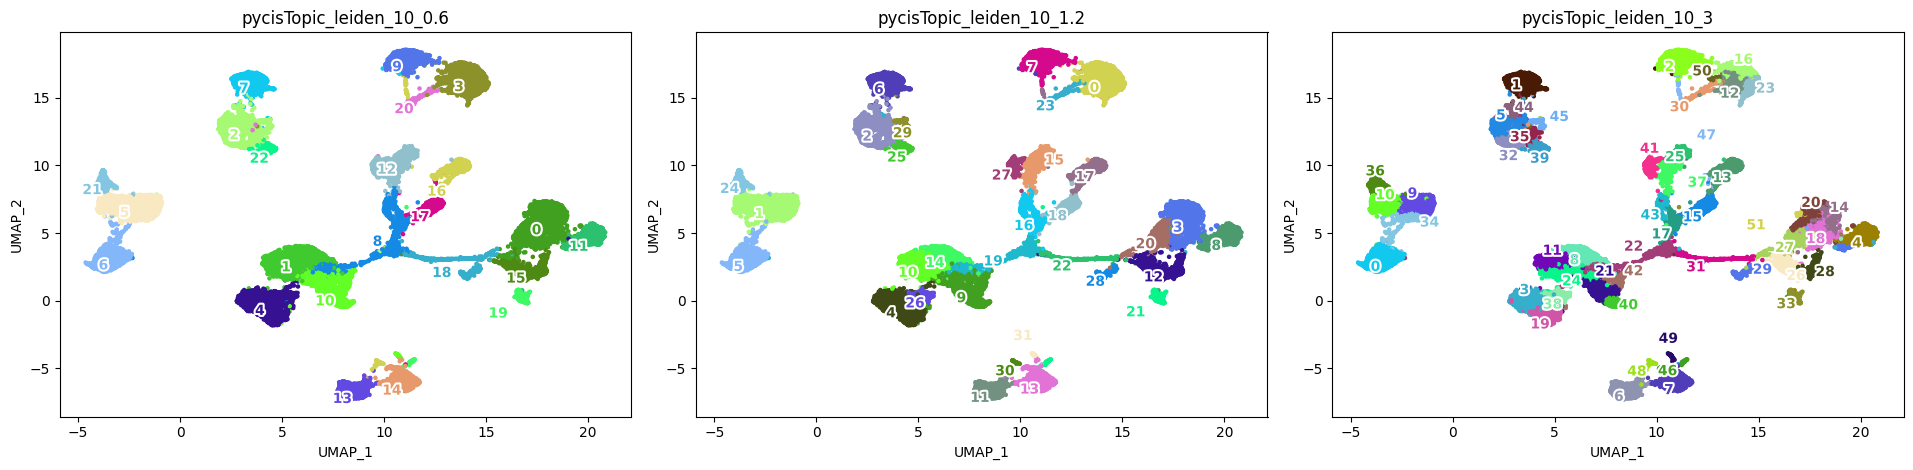

In [16]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['pycisTopic_leiden_10_0.6', 'pycisTopic_leiden_10_1.2', 'pycisTopic_leiden_10_3'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=5)

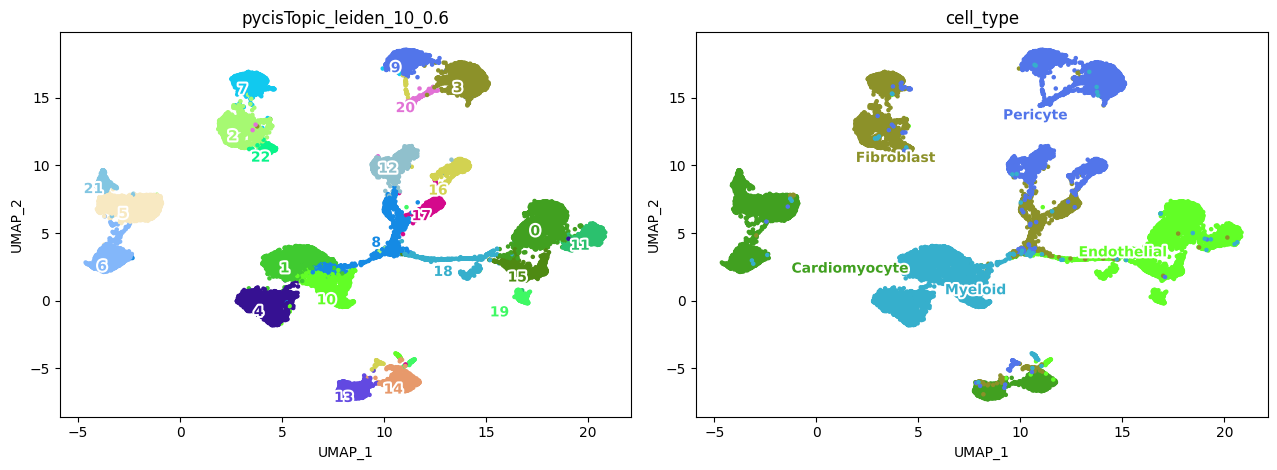

In [18]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['pycisTopic_leiden_10_0.6', 'cell_type'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=5)

### Plot by the age and disease status

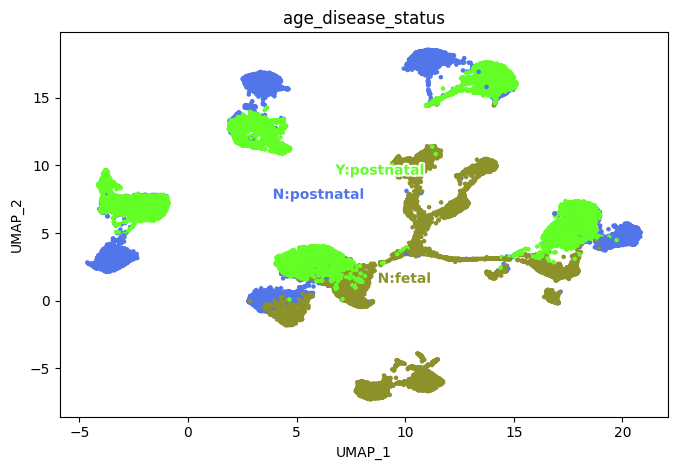

In [19]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['age_disease_status'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=5)